# Crypto perpetuals: what the search actually found

Four notebooks narrowed a field. [`13_backtest`](13_backtest.ipynb) ran every prediction set
equally weighted, [`14_portfolio_management`](14_portfolio_management.ipynb) sized the survivors
six ways, [`15_risk_management`](15_risk_management.ipynb) tried fourteen ways of leaving a
position early, and [`16_costs`](16_costs.ipynb) asked how much friction the survivor absorbs.
This notebook makes the one choice the case study exists to make, and then says how much
confidence that choice supports.

**The second half is the part that matters.** A funnel that ranks several hundred backtests on
one validation period will always return a highest number. Whether that number is evidence
depends on how many candidates it was the highest of, how wide its own confidence interval is,
and how much of it is left after correcting for having been selected. Reporting the selected
row without those three is the failure this notebook is built to avoid.

**Learning objectives.** By the end of this notebook you will be able to:

- Select one configuration across labels, and say why the label is part of the configuration
  rather than a separate axis.
- Read a Sharpe ratio as an interval rather than a point, and say what the interval covers.
- Apply a selection-bias correction and say what the corrected number means when the raw one is
  already negative.
- Separate what a perpetual-futures strategy earns from price movement and from funding.

**Book reference**: Chapter 20 (Strategy Synthesis).

**Prerequisites**: [`15_risk_management`](15_risk_management.ipynb) has frozen a candidate set
per label spanning all three selection stages.

**What it writes**: one candidate set holding the whole selection pool. No backtests, no
training, no holdout evaluation.

In [1]:
"""Select and assess one crypto perpetuals configuration from the frozen validation pool."""

import sqlite3
from contextlib import closing

import plotly.graph_objects as go
import polars as pl

from case_studies.crypto_perps_funding.research_workflow import (
    ALL_LABELS,
)
from case_studies.research import (
    HORIZON_DEPENDENT_PROTOCOL_FIELDS,
    CandidateSet,
    Result,
    candidate_set_supersedes,
    open_study,
)
from case_studies.utils.uncertainty import (
    compute_backtest_uncertainty,
    compute_cohort_metrics,
    load_daily_returns_with_timestamp,
    periods_per_year_from_setup,
)
from utils.style import COLORS, show_plotly_with_alt

In [2]:
LABELS: list[str] = []
EXECUTION_TIER = "canonical"
WORKSPACE: str = ""
# The generation of `crypto-final-selection` this run replaces. Its membership is the union of
# the four final validation sets, and those moved in `15_risk_management` when the grid their
# admission rule is applied to stopped being every row the registry holds for the label - so
# this pool moves with them. Recorded here rather than passed at run time: `supersedes` is part
# of what identifies the generation, so a re-run declaring nothing computes a different hash
# from the row on record and is refused (ml4t/agent-workspace#879).
# Left empty, and it stays empty. The registry was reset for the stage-04 holdout rebuild, so
# every name below is published at generation one and there is nothing to supersede. A
# declaration is only needed when a re-run changes an existing name's membership: the refusal
# prints the name and the hash, and it is resolved through the shared resolver rather than
# offered straight, because a reader's clean clone has no generation for it to replace.
SUPERSEDES: str = ""

In [3]:
study = open_study(
    "crypto_perps_funding", execution_tier=EXECUTION_TIER, workspace=WORKSPACE or None
)
labels = list(LABELS) if LABELS else list(ALL_LABELS)
# Where this run's own results are written and read back from: the released case directory on a
# canonical run, the isolated preview directory otherwise. `study.root` is the released one in
# both tiers, so a preview that reads it is reading somebody else's registry.
STORAGE_ROOT = study.storage_root(study.execution_tier)
periods_per_year = periods_per_year_from_setup("crypto_perps_funding")

## 1. One pool, four labels

Each label has its own frozen set spanning the baseline, allocation and overlay stages. The
object of selection is **one configuration for the case study**, not one per label, so the four
sets are compared as a single pool and the label comes from the row that is selected.

The four labels are not interchangeable inputs to one experiment. `fwd_ret_8h` and
`fwd_ret_24h` are continuous returns over different horizons; `fwd_dir_8h` and `fwd_dir_8h_3c`
are the 8-hour move coded into two and three classes. Three things about the protocol move with
the horizon and nothing else does: the label artifact, the purge interval inside the
cross-validation split, and the feature artifacts, because the model-based features are fit per
label. A candidate set spanning the four has to declare those three as the axis it spans, which
is what `comparable_fields` does below, and `HORIZON_DEPENDENT_PROTOCOL_FIELDS` is the one
definition of that list rather than a copy of it. Everything else must still match: the set
refuses a member whose split or execution tier disagrees.

In [4]:
pool_members = []
for label in labels:
    candidates = CandidateSet.one(study, name=f"crypto-final-validation-{label}")
    pool_members.extend(Result.open(study, member) for member in candidates.members)
POOL_NAME = "crypto-final-selection"
pool = CandidateSet.create(
    study,
    POOL_NAME,
    pool_members,
    comparison_contract={"comparable_fields": list(HORIZON_DEPENDENT_PROTOCOL_FIELDS)},
    # Resolved rather than offered, for the reason `14` and `16` record: the declaration is
    # committed source and a reader's clean clone has no generation for it to replace.
    supersedes=candidate_set_supersedes(study, name=POOL_NAME, declared=SUPERSEDES),
)
print(f"{len(pool.members)} candidates across {len(labels)} labels")

2807 candidates across 4 labels


## 2. The selection

Highest validation Sharpe in the pool, which is the rule the whole funnel has applied at every
stage. It is applied here across labels for the first time.

In [5]:
selected = pool.best_validation_sharpe()
catalog = study.backtests.table().filter(pl.col("backtest_hash").is_in(pool.members))
if catalog.height != len(pool.members):
    raise RuntimeError("the backtest catalog does not describe every candidate")

The selected configuration, and the pool it was selected from. The stage column says how far
down the funnel the selection came from: a baseline row means neither sizing nor an overlay
improved on equal weight for that ranking.

In [6]:
keyed = catalog.with_columns(
    pl.col("allocation_method").fill_null("equal_weight").alias("allocator"),
    pl.col("risk_method").fill_null("none").alias("overlay"),
)
keyed.filter(pl.col("backtest_hash") == selected.hash).select(
    "label",
    "family",
    "config_name",
    "checkpoint_kind",
    "checkpoint_value",
    "stage",
    "signal_method",
    "allocator",
    "overlay",
    "sharpe",
    "max_drawdown",
    "total_return",
    "num_trades",
)

label,family,config_name,checkpoint_kind,checkpoint_value,stage,signal_method,allocator,overlay,sharpe,max_drawdown,total_return,num_trades
str,str,str,str,i64,str,str,str,str,f64,f64,f64,f64
"""fwd_ret_24h""","""linear""","""ridge_a100000.0""","""final""",null,"""risk_overlay""","""equal_weight_top_k""","""mvo_ledoit_wolf""","""time_exit_20""",1.574462,-0.398105,3.638535,808.0


What it was selected from, by stage. The spread within each stage is the more useful number
than any single row: it says how much of the difference between candidates is available to be
picked up by chance.

In [7]:
keyed.group_by("stage").agg(
    candidates=pl.len(),
    labels=pl.col("label").n_unique(),
    best_sharpe=pl.col("sharpe").max(),
    median_sharpe=pl.col("sharpe").median(),
    worst_sharpe=pl.col("sharpe").min(),
    above_zero=(pl.col("sharpe") > 0).sum(),
).sort("stage")

stage,candidates,labels,best_sharpe,median_sharpe,worst_sharpe,above_zero
str,u32,u32,f64,f64,f64,u32
"""allocation""",720,4,1.479354,-0.322927,-1.38083,71
"""risk_overlay""",56,4,1.574462,-0.049828,-3.825895,26
"""signal""",2031,4,1.271052,-1.931969,-4.422003,207


## 3. How much confidence the selection supports

Three separate questions, and they have different answers.

**How precise is this one number?** A stationary block bootstrap on the selected result's
own daily return series gives a ninety-five percent interval, with the block length taken
from the label's rebalance step so that the resampling respects the holding period. That
interval describes sampling variation in one series and says nothing about the search.

**How much of it is selection?** The selected Sharpe is the maximum over the whole pool, and the
maximum of many draws is above the truth even when every draw is worthless. The **deflated
Sharpe ratio** subtracts what the maximum would have been under a null of no skill. Three
variants are computed: a raw one that treats every candidate as an independent trial, and two
that discount correlated candidates - which matters here, because a hundred backtests on twenty
prediction sets are anything but independent.

**How long would it take to know?** `min_trl` is the number of periods the selected strategy
would need to run for its Sharpe to reach significance at the conventional five percent level.
Where it exceeds the data available, the honest statement is that the validation period cannot
settle the question.

The alignment below intersects the candidates on timestamp. That is only safe because both
earlier stages admitted to their candidate sets on **folds traded** rather than on periods
observed - a result that sat out a fold would align perfectly here and be scored on a different
period, which is exactly the comparison the funnel is meant to prevent.

In [8]:
selected_returns = load_daily_returns_with_timestamp("crypto_perps_funding", selected.hash)
if selected_returns is None:
    raise RuntimeError("the selected result has no registered return series")
selected_label = keyed.filter(pl.col("backtest_hash") == selected.hash).item(0, "label")
interval = compute_backtest_uncertainty(
    selected_returns,
    periods_per_year=periods_per_year,
    case_study="crypto_perps_funding",
    label=selected_label,
)

In [9]:
returns_by_hash = {}
for member in pool.members:
    frame = load_daily_returns_with_timestamp("crypto_perps_funding", member)
    if frame is None:
        raise RuntimeError(f"pool member {member} has no registered return series")
    returns_by_hash[member] = frame
cohort = compute_cohort_metrics(returns_by_hash, periods_per_year=periods_per_year)
if not cohort:
    raise RuntimeError("cohort alignment failed across the selection pool")

The alignment intersects the pool on timestamp, and the intersection has to be the whole of
the shortest member's own series. If it is shorter than that, members disagree about *which*
dates they cover rather than about how many, and the corrections below would be computed on a
period none of them was measured over. The check is exact and carries no tolerance.

When the intersection is clean, the ranking on it can still differ from the registered one by a
place, because each registered Sharpe was computed on that result's own series and these are
computed on the common one. That is a real difference, and it stops this notebook rather than
being reported alongside the result.

The reason is that `compute_cohort_metrics` computes its Sharpe, its Rademacher bound and all
three deflated Sharpes for whichever member leads the common period, while the interval and
the PSR below are computed for the registered selection. When those are the same result the
table reads as one strategy, which is what it claims to be. When they are not, the same table
would carry two strategies' numbers under one heading, and nothing in it would say so.

In [10]:
aligned_periods = int(cohort["n_periods"]) if "n_periods" in cohort else None
shortest = min(frame.height for frame in returns_by_hash.values())
longest = max(frame.height for frame in returns_by_hash.values())
if aligned_periods is not None and aligned_periods < shortest:
    raise RuntimeError(
        f"the pool intersects to {aligned_periods} periods but its shortest member has "
        f"{shortest}, so members cover different dates rather than different amounts"
    )
print(
    f"members span {shortest} to {longest} periods and intersect on "
    f"{aligned_periods if aligned_periods is not None else shortest}"
)
if cohort["leader_hash"] != selected.hash:
    raise RuntimeError(
        f"on the common period the highest Sharpe is {cohort['leader_hash']}, not the "
        f"registered selection {selected.hash}. The cohort statistics below describe the "
        "common-period leader and the interval describes the selection, so publishing them "
        "together would report two strategies as one. Re-select on the aligned period."
    )

members span 729 to 730 periods and intersect on 729


The selected configuration read three ways. `sharpe` is what it scored; `ras_sharpe` is a lower
bound that holds across the whole search; the three `dsr_*` rows are the selection-corrected
Sharpe under different assumptions about how independent the candidates were.

In [11]:
pl.DataFrame(
    [
        {
            "metric": name,
            "value": {**interval, **cohort}.get(key),
        }
        for name, key in [
            ("candidates (K)", "k_variants"),
            ("selected Sharpe", "leader_sharpe"),
            ("Sharpe, 95% interval low", "sharpe_ci95_lo"),
            ("Sharpe, 95% interval high", "sharpe_ci95_hi"),
            ("probabilistic Sharpe p-value", "psr_pvalue"),
            ("bootstrap block length", "bootstrap_block_length"),
            ("expected max Sharpe under the null", "expected_max_sharpe_raw"),
            ("deflated Sharpe, raw K", "dsr_raw"),
            ("deflated Sharpe, Marchenko-Pastur K", "dsr_mp"),
            ("deflated Sharpe, effective-rank K", "dsr_er"),
            ("Rademacher-adjusted Sharpe", "ras_leader"),
            ("periods needed for significance, effective-rank K", "min_trl_periods_er"),
        ]
        if key in {**interval, **cohort}
    ]
)

metric,value
str,f64
"""candidates (K)""",2807.0
"""selected Sharpe""",1.574462
"""Sharpe, 95% interval low""",0.272231
"""Sharpe, 95% interval high""",2.803933
"""probabilistic Sharpe p-value""",0.010677
…,…
"""deflated Sharpe, raw K""",-0.149167
"""deflated Sharpe, Marchenko-Pas…",-0.062162
"""deflated Sharpe, effective-ran…",-0.065036


## 4. What the selected strategy did

The cumulative return of the selected configuration across the validation folds, against the
zero line. Funding is settled inside the engine at each 8-hourly timestamp on the position held
before that timestamp's fills, so the curve already includes it.

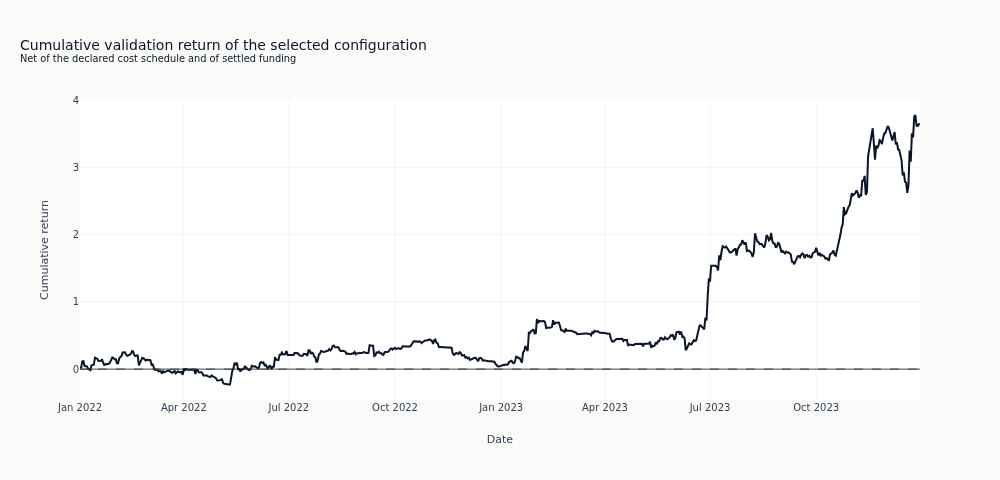

In [12]:
returns = returns_by_hash[selected.hash].sort("timestamp")
column = next(name for name in returns.columns if name != "timestamp")
equity = returns.with_columns(cumulative=(1.0 + pl.col(column)).cum_prod() - 1.0)
fig = go.Figure()
fig.add_trace(
    go.Scatter(
        x=equity.get_column("timestamp").to_list(),
        y=equity.get_column("cumulative").to_list(),
        mode="lines",
        name="selected configuration",
        line={"color": COLORS["blue"]},
    )
)
fig.add_hline(y=0, line_width=1, line_dash="dash", line_color=COLORS["neutral"])
fig.update_layout(
    title={
        "text": "Cumulative validation return of the selected configuration"
        "<br><sup>Net of the declared cost schedule and of settled funding</sup>",
        "x": 0.02,
        "xanchor": "left",
    },
    xaxis_title="Date",
    yaxis_title="Cumulative return",
    height=480,
    width=1000,
)
show_plotly_with_alt(
    fig,
    "Line chart of the cumulative validation return of the selected configuration over the two "
    "validation folds, with a dashed horizontal line at zero, net of declared costs and settled "
    "funding.",
)

### Where the money came from

A perpetual-futures strategy has two sources of return that behave differently, and a total
return hides which one it used. Price P&L is the contract moving; funding is the periodic
payment between longs and shorts, settled every eight hours on whatever position is held. A
strategy whose return is mostly funding is a carry strategy whether or not it was built as one,
and it will behave completely differently when the funding rate changes sign.

The shared backtest catalog projects the metrics every case study has in common, and funding
is not among them - it exists only where the instrument settles it. Reading it from the
registry keeps the column available without widening a shared catalog for one case study's
economics.

In [13]:
with closing(
    sqlite3.connect(f"file:{STORAGE_ROOT / 'run_log' / 'registry.db'}?mode=ro", uri=True)
) as db:
    funding_row = db.execute(
        "SELECT funding_pnl, funding_events, funding_settlements FROM backtest_metrics "
        "WHERE backtest_hash = ?",
        (selected.hash,),
    ).fetchone()
if funding_row is None:
    raise RuntimeError("the selected result has no registered metrics row")
record = keyed.filter(pl.col("backtest_hash") == selected.hash)
pl.DataFrame(
    [
        {
            "funding_pnl": funding_row[0],
            "funding_events": funding_row[1],
            "funding_settlements": funding_row[2],
            "total_commission": record.item(0, "total_commission"),
            "total_slippage": record.item(0, "total_slippage"),
            "total_return": record.item(0, "total_return"),
        }
    ]
)

funding_pnl,funding_events,funding_settlements,total_commission,total_slippage,total_return
f64,f64,f64,f64,f64,f64
12091.051828,1616.0,42313.0,35458.787146,8864.69866,3.638535


## 5. The holdout, and what it does to section 3

`config/setup.yaml` reserves 2024 and 2025 as a holdout. Nothing above was fitted, selected or
measured on it: the pool is frozen and immutable, so the configuration could not be re-chosen
after the holdout result was seen. Every stage of the funnel exists to make that sentence true.

Measuring it takes three steps, in this order: refit the selected configuration on training
plus validation, predict the holdout window, and replay that one configuration through the
same backtest specification. That is [`17_holdout_predictions`](17_holdout_predictions.ipynb)
and [`18_holdout_backtest`](18_holdout_backtest.ipynb), and both have now run.

It is not that the window may only ever be measured once. The rule forbids selecting on the
holdout, not recomputing it: a result found to be wrong is deleted and produced again, and
what the two notebooks guard is that only one generation is readable at a time, so nobody
downstream can quote whichever number they prefer.

In [14]:
holdout_predictions = study.predictions.table().filter(pl.col("split") == "holdout")
with closing(
    sqlite3.connect(f"file:{STORAGE_ROOT / 'run_log' / 'registry.db'}?mode=ro", uri=True)
) as db:
    holdout_metrics = db.execute(
        "SELECT m.sharpe, m.cagr, m.max_drawdown, m.n_periods "
        "FROM backtest_metrics m JOIN backtest_runs r ON r.backtest_hash = m.backtest_hash "
        "WHERE r.stage = 'holdout'",
    ).fetchall()
print(
    f"{holdout_predictions.height} holdout prediction set(s) in the registry; "
    f"selection pool {pool.hash} is frozen at {len(pool.members)} members"
)
for sharpe, cagr, max_drawdown, n_periods in holdout_metrics:
    print(
        f"  holdout Sharpe {sharpe:.3f} over {int(n_periods):,} periods, "
        f"CAGR {cagr:.1%}, max drawdown {max_drawdown:.2%}"
    )

1 holdout prediction set(s) in the registry; selection pool 25e72ae52f9c is frozen at 2807 members
  holdout Sharpe -0.649 over 731 periods, CAGR -39.2%, max drawdown -74.93%


The holdout Sharpe is negative, on the configuration section 3 measured at a validation
Sharpe of 1.57, with a bootstrap interval excluding zero and a probabilistic Sharpe p-value
of 0.011. Every uncorrected statistic there said the strategy worked. The deflated Sharpe, at
-0.15, said it did not, and the holdout agrees with the deflation.

This is one draw and it is not proof that the deflation is right in general. What it does
establish is that the disagreement in section 3 was not academic: a reader who stopped at the
interval and the p-value, both correctly computed, would have carried a strategy into 2024
that lost money over two years. The correction was the only number that anticipated it.

The sign is what carries the lesson here, not the magnitude. A drawdown this deep on nineteen
perpetual contracts over two years also reflects the leverage the allocator took and the
absence of any position-level stop beyond the selected time exit, so the holdout should be
read as the direction of the edge, not as a calibrated forecast of what this configuration
would have returned in production.

## 6. What to notice

**The funnel narrows the search, it does not remove it.** Every stage ran fewer configurations
than the one before, which is why the pool is in the hundreds rather than the thousands. It is
still a search, and the correction in section 3 is the price of having run it. A case study
that reported only the highest Sharpe would be reporting the largest of several hundred draws
as though it were one measurement.

**Every uncorrected statistic here says the selection is real, and the correction says it is
not.** The selected configuration posts a validation Sharpe of 1.57. Its bootstrap interval is
[0.27, 2.80] and excludes zero; its probabilistic Sharpe p-value is 0.0107; it needs 374 periods
to reach significance and it has 729. Read on their own, all four say the strategy works. The
deflated Sharpe is -0.15, and under either shrunk trial count it is still below zero. The
disagreement is not a contradiction: the interval and the p-value are computed for one series
and answer whether *this* return stream differs from zero, while the deflation asks whether the
best of 2,807 differs from what the best of 2,807 worthless strategies would have produced. The
largest of 2,807 draws lands near 1.6 whether or not any of them has an edge, so 1.57 is what
this search returns when nothing works.

That is the whole reason the pool is frozen before it is read. A case study free to stop at the
interval would have reported a Sharpe of 1.57 significant at the 1% level, with each supporting
number correctly computed.

**The interval and the correction answer different questions.** The bootstrap interval widens
with a shorter series; the deflation grows with more candidates. A long backtest of one strategy
has a tight interval and no deflation. A short backtest of five hundred has both problems, and
two validation folds of 8-hourly crypto data is closer to the second.

The Rademacher-adjusted Sharpe of 1.09 stays positive where the deflated Sharpe does not, and
the two are not interchangeable. It penalizes the complexity of the strategy class by what the
same procedure achieves on permuted returns; the deflation penalizes the number of draws taken.
On a pool this size the count dominates, so where they disagree the deflation is the one being
asked the question this stage exists to ask.

**Funding is a separate return stream, not a cost line.** It is reported beside commission and
slippage above because all three reduce or increase the same total, but it is the only one that
depends on holding rather than trading, and the only one that can be positive.

**Known limitations.** Everything above is measured on two validation folds spanning 2022 and
2023, on nineteen perpetual contracts, at one declared cost schedule. The pool contains only
configurations that traded both folds, so nothing here says how a strategy that trades
selectively would compare - by construction it could not have been ranked against these. The
holdout in section 5 checks the selected configuration out of sample and nothing else: every
other statement above is a validation statement.